# ARTI403 — Image Processing · Lab 1 — Solutions

In [1]:
%matplotlib inline
import os
import numpy as np
import cv2
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
matplotlib.rcParams['figure.dpi'] = 72

# Build the images/ folder from scikit-image sample data
from skimage import data
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.util import img_as_ubyte
import imageio.v3 as iio

os.makedirs("images", exist_ok=True)
iio.imwrite("images/cameraman.tif", data.camera())                       # cameraman, 512x512 uint8
iio.imwrite("images/lena_gray_256.tif",
            img_as_ubyte(resize(rgb2gray(data.astronaut()), (256, 256), anti_aliasing=True)))
iio.imwrite("images/coffee.png", data.coffee())                          # colour sample

print(sorted(os.listdir("images")))

['cameraman.tif', 'coffee.png', 'lena_gray_256.tif']


## Task #2 — Loading and Visualizing Images

### (a) Loading/reading an image using OpenCV

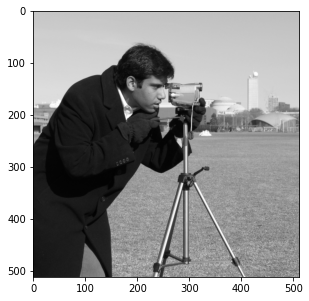

In [2]:
import cv2
img = cv2.imread('images/cameraman.tif')   # Load the image data into a NumPy array

import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

Two things the cell above hides:

1. `cv2.imread` defaults to `IMREAD_COLOR`, so a grayscale TIF comes back as **3 identical channels**. Use `cv2.IMREAD_GRAYSCALE` for a true 2-D array.
2. OpenCV orders channels **BGR**, Matplotlib expects **RGB**. Harmless on gray, but it swaps red and blue on colour images. Fix with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

default imread  : (512, 512, 3) uint8 -> 3 channels (BGR)
IMREAD_GRAYSCALE: (512, 512) uint8 -> single channel
channels identical? True


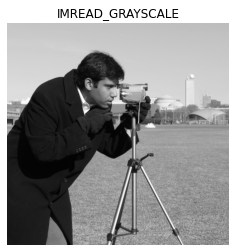

In [3]:
img_gray = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)
print("default imread  :", img.shape, img.dtype, "-> 3 channels (BGR)")
print("IMREAD_GRAYSCALE:", img_gray.shape, img_gray.dtype, "-> single channel")
print("channels identical?", np.array_equal(img[:, :, 0], img[:, :, 2]))

plt.figure(figsize=(4, 4))
plt.imshow(img_gray, cmap='gray'); plt.title("IMREAD_GRAYSCALE"); plt.axis('off'); plt.show()

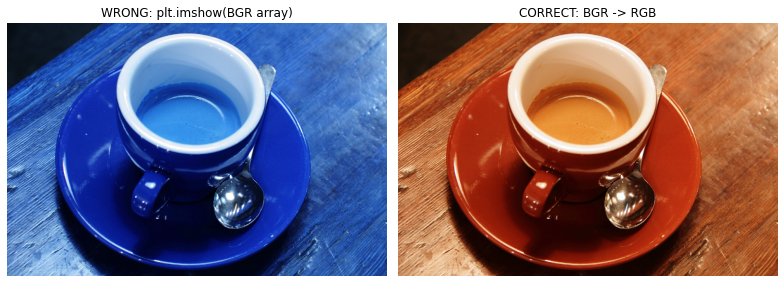

In [4]:
bgr = cv2.imread('images/coffee.png')            # OpenCV -> BGR
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)      # corrected -> RGB

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(bgr); ax[0].set_title("WRONG: plt.imshow(BGR array)"); ax[0].axis('off')
ax[1].imshow(rgb); ax[1].set_title("CORRECT: BGR -> RGB"); ax[1].axis('off')
plt.tight_layout(); plt.show()

### (b) Loading/reading image using PIL

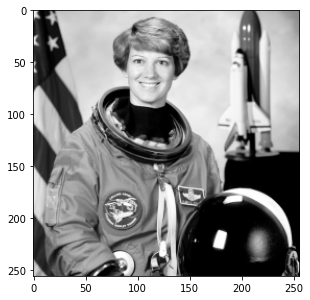

In [5]:
from PIL import Image
img2 = Image.open('images/lena_gray_256.tif')   # load image into a PIL Image object

import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.imshow(img2, cmap = cm.Greys_r)
plt.show()

In [6]:
print("type   :", type(img2))
print("format :", img2.format)
print("mode   :", img2.mode, "(L = 8-bit grayscale)")
print("size   :", img2.size, "-> PIL reports (WIDTH, HEIGHT); NumPy shape is (HEIGHT, WIDTH)")

type   : <class 'PIL.TiffImagePlugin.TiffImageFile'>
format : TIFF
mode   : L (L = 8-bit grayscale)
size   : (256, 256) -> PIL reports (WIDTH, HEIGHT); NumPy shape is (HEIGHT, WIDTH)


## Task #3 — Image Storing

### (a) Saving image to disk using OpenCV

In [7]:
ok = cv2.imwrite('new_image.jpg', img)
print("cv2.imwrite returned:", ok, "| size:", os.path.getsize('new_image.jpg'), "bytes")

cv2.imwrite returned: True | size: 86612 bytes


### (b) Saving an image to disk using PIL

In [8]:
img2.save('new_image2.jpg')
print("saved new_image2.jpg:", os.path.getsize('new_image2.jpg'), "bytes")

saved new_image2.jpg: 11981 bytes


**JPEG is lossy** — the reloaded pixels are not bit-identical to the originals. TIF/PNG are lossless.

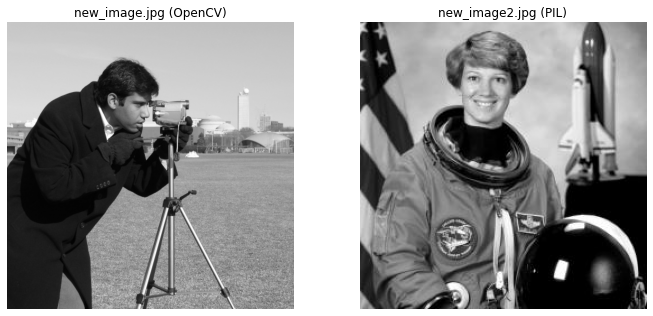

identical to original? False
max JPEG error: 9 | mean error: 0.953
out_lossless.png    148,344 bytes
out_q95.jpg          85,033 bytes
out_q25.jpg          13,915 bytes


In [9]:
check1 = cv2.imread('new_image.jpg', cv2.IMREAD_GRAYSCALE)
check2 = np.array(Image.open('new_image2.jpg'))

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
ax[0].imshow(check1, cmap='gray'); ax[0].set_title("new_image.jpg (OpenCV)");  ax[0].axis('off')
ax[1].imshow(check2, cmap='gray'); ax[1].set_title("new_image2.jpg (PIL)");    ax[1].axis('off')
plt.tight_layout(); plt.show()

diff = np.abs(check1.astype(int) - img_gray.astype(int))
print("identical to original?", np.array_equal(check1, img_gray))
print(f"max JPEG error: {diff.max()} | mean error: {diff.mean():.3f}")

for fname, saver in [('out_lossless.png', lambda p: cv2.imwrite(p, img_gray)),
                     ('out_q95.jpg', lambda p: cv2.imwrite(p, img_gray, [cv2.IMWRITE_JPEG_QUALITY, 95])),
                     ('out_q25.jpg', lambda p: cv2.imwrite(p, img_gray, [cv2.IMWRITE_JPEG_QUALITY, 25]))]:
    saver(fname); print(f"{fname:18s} {os.path.getsize(fname):>8,} bytes")

## Task #4 — Display image as an Array

In [10]:
print(img.shape)   # img loaded using OpenCV is a numpy array
print(img)

(512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [11]:
import numpy as np

# Convert the image to a NumPy array
img_array = np.array(img2)

# Print the array
print(img_array.shape)
print(img_array)

(256, 256)
[[142  93 117 ... 120 120 117]
 [197 178 184 ... 118 119 118]
 [225 217 211 ... 119 119 119]
 ...
 [172 174 168 ...  62  27   0]
 [173 170 159 ...  48   3   0]
 [171 164 147 ...  77  22   0]]


In [12]:
print("shape  :", img_array.shape, "-> (rows=height, cols=width)")
print("dtype  :", img_array.dtype, "-> 8-bit unsigned integer, 0=black .. 255=white")
print("size   :", img_array.size, "pixels")
print("memory :", img_array.nbytes, "bytes =", img_array.nbytes / 1024, "KB")
print("range  :", img_array.min(), "to", img_array.max())
print("\nTop-left 8x8 block of raw pixel values:\n")
print(img_array[:8, :8])

shape  : (256, 256) -> (rows=height, cols=width)
dtype  : uint8 -> 8-bit unsigned integer, 0=black .. 255=white
size   : 65536 pixels
memory : 65536 bytes = 64.0 KB
range  : 0 to 254

Top-left 8x8 block of raw pixel values:

[[142  93 117 148 149 104  34   4]
 [197 178 184 190 160  85  17   5]
 [225 217 211 190 132  48  14   6]
 [229 224 208 169  90  32  15   6]
 [223 218 205 164  83  33  18   7]
 [222 219 209 183 131  60  19   9]
 [224 220 211 200 170 113  42  10]
 [217 201 181 179 174 145  88  22]]


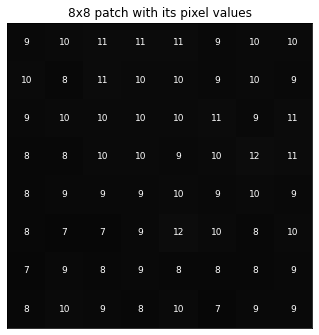

In [13]:
# The picture and its numbers are the same thing
patch = img_array[100:108, 100:108]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(patch, cmap='gray', vmin=0, vmax=255)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        v = patch[i, j]
        ax.text(j, i, str(v), ha='center', va='center', fontsize=9,
                color='black' if v > 127 else 'white')
ax.set_title("8x8 patch with its pixel values"); ax.set_xticks([]); ax.set_yticks([])
plt.show()

# Assessment — NumPy operations on the image array

All operations are performed on `img_array`, the array of `lena_gray_256.tif`.

### A1 — Indexing and slicing

img_array[0, 0]       = 142
img_array[128, 128]   = 17
img_array[-1, -1]     = 0
first row  [0, :5]    = [142  93 117 148 149]
first col  [:5, 0]    = [142 197 225 229 223]


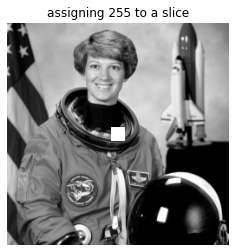

In [14]:
print("img_array[0, 0]       =", img_array[0, 0])
print("img_array[128, 128]   =", img_array[128, 128])
print("img_array[-1, -1]     =", img_array[-1, -1])
print("first row  [0, :5]    =", img_array[0, :5])
print("first col  [:5, 0]    =", img_array[:5, 0])

edited = img_array.copy()
edited[120:136, 120:136] = 255          # write into a slice
plt.figure(figsize=(4, 4))
plt.imshow(edited, cmap='gray', vmin=0, vmax=255)
plt.title("assigning 255 to a slice"); plt.axis('off'); plt.show()

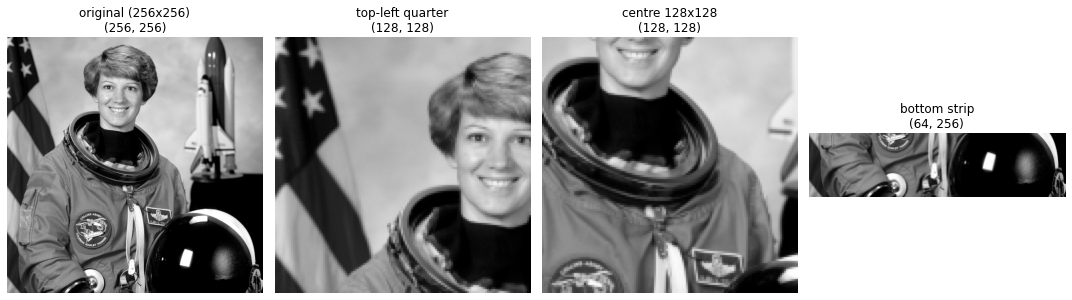

In [15]:
crops = {"original (256x256)": img_array,
         "top-left quarter":   img_array[:128, :128],
         "centre 128x128":     img_array[64:192, 64:192],
         "bottom strip":       img_array[192:, :]}
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr) in zip(ax, crops.items()):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(f"{t}\n{arr.shape}"); a.axis('off')
plt.tight_layout(); plt.show()

### A2 — Geometric operations (pure index manipulation, no image library)

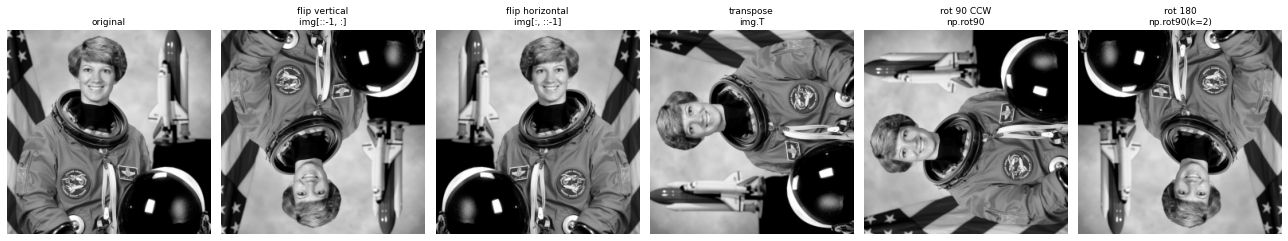

In [16]:
ops = {"original": img_array,
       "flip vertical\nimg[::-1, :]":   img_array[::-1, :],
       "flip horizontal\nimg[:, ::-1]": img_array[:, ::-1],
       "transpose\nimg.T":              img_array.T,
       "rot 90 CCW\nnp.rot90":          np.rot90(img_array),
       "rot 180\nnp.rot90(k=2)":        np.rot90(img_array, k=2)}
fig, ax = plt.subplots(1, 6, figsize=(18, 3.4))
for a, (t, arr) in zip(ax, ops.items()):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

### A3 — Arithmetic: brightness, contrast, gamma, negative

`uint8` arithmetic **wraps around** (200 + 100 = 44). Cast to a wider type → compute → `np.clip` → cast back.

/tmp/ipykernel_90/939099222.py:1: RuntimeWarning: overflow encountered in scalar add
  print("uint8 overflow:", np.uint8(200) + np.uint8(100), " <- expected 300, got 300 mod 256")


uint8 overflow: 44  <- expected 300, got 300 mod 256


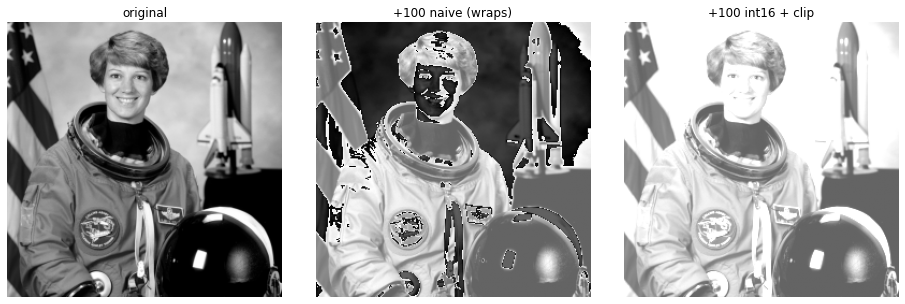

In [17]:
print("uint8 overflow:", np.uint8(200) + np.uint8(100), " <- expected 300, got 300 mod 256")

naive = img_array + 100                                                        # WRONG
safe  = np.clip(img_array.astype(np.int16) + 100, 0, 255).astype(np.uint8)     # CORRECT

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (t, arr) in zip(ax, [("original", img_array),
                            ("+100 naive (wraps)", naive),
                            ("+100 int16 + clip", safe)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

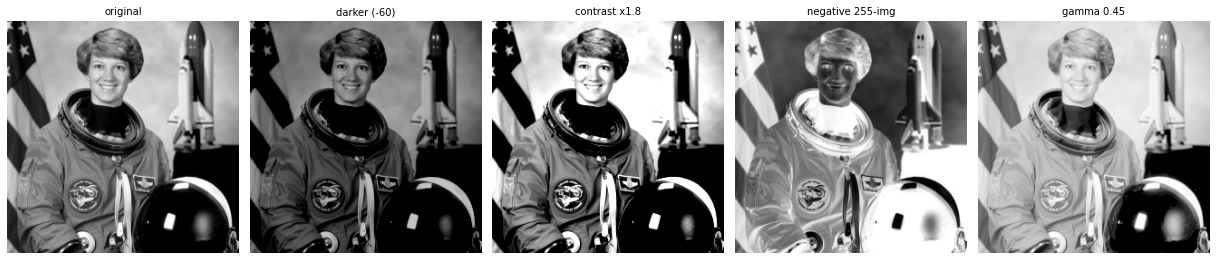

In [18]:
darker   = np.clip(img_array.astype(np.int16) - 60, 0, 255).astype(np.uint8)
contrast = np.clip((img_array.astype(np.float32) - 128) * 1.8 + 128, 0, 255).astype(np.uint8)
negative = 255 - img_array
gamma    = np.clip(((img_array / 255.0) ** 0.45) * 255, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 5, figsize=(17, 3.8))
for a, (t, arr) in zip(ax, [("original", img_array), ("darker (-60)", darker),
                            ("contrast x1.8", contrast), ("negative 255-img", negative),
                            ("gamma 0.45", gamma)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

### A4 — Boolean masking and thresholding

mask dtype: bool | shape: (256, 256)
pixels brighter than 100: 39,125 of 65,536 (59.7%)


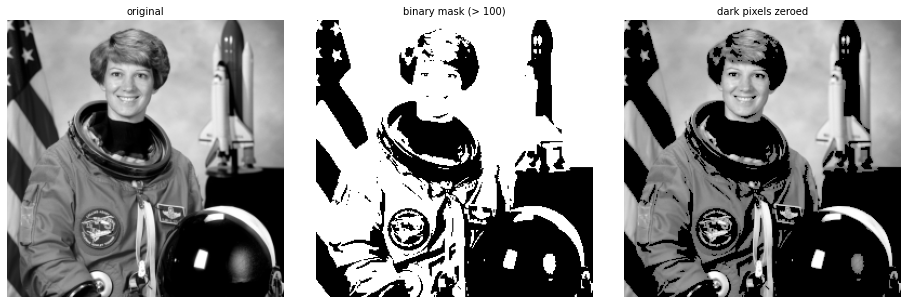

In [19]:
T = 100
mask = img_array > T                       # boolean array, same shape
binary = (mask * 255).astype(np.uint8)

print("mask dtype:", mask.dtype, "| shape:", mask.shape)
print(f"pixels brighter than {T}: {mask.sum():,} of {mask.size:,} ({100*mask.mean():.1f}%)")

masked = img_array.copy()
masked[~mask] = 0

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, (t, arr) in zip(ax, [("original", img_array), (f"binary mask (> {T})", binary),
                            ("dark pixels zeroed", masked)]):
    a.imshow(arr, cmap='gray', vmin=0, vmax=255); a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

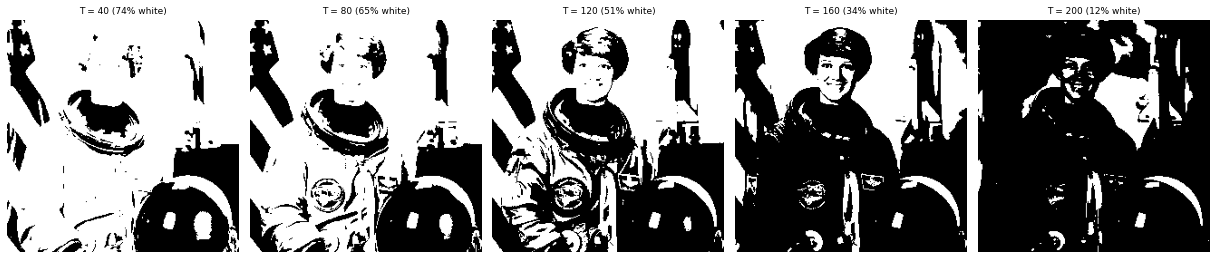

In [20]:
fig, ax = plt.subplots(1, 5, figsize=(17, 3.6))
for a, t in zip(ax, [40, 80, 120, 160, 200]):
    a.imshow((img_array > t) * 255, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"T = {t} ({100*(img_array > t).mean():.0f}% white)", fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

### A5 — Statistics and histogram

In [21]:
print(f"min      : {img_array.min()}")
print(f"max      : {img_array.max()}")
print(f"mean     : {img_array.mean():.2f}")
print(f"median   : {np.median(img_array):.2f}")
print(f"std dev  : {img_array.std():.2f}")
print(f"variance : {img_array.var():.2f}")
print(f"sum      : {img_array.sum():,}")
print(f"25/50/75 percentiles: {np.percentile(img_array, [25, 50, 75])}")
print("\nmean of first 5 rows   :", img_array.mean(axis=1)[:5].round(2))
print("mean of first 5 columns:", img_array.mean(axis=0)[:5].round(2))

min      : 0
max      : 254
mean     : 112.70
median   : 123.00
std dev  : 74.37
variance : 5530.60
sum      : 7,385,832
25/50/75 percentiles: [ 39. 123. 179.]

mean of first 5 rows   : [162.96 163.98 164.55 164.63 165.19]
mean of first 5 columns: [114.9  112.04 110.12 106.73 101.69]


hist.shape = (256,) | total counts = 65536 = number of pixels
most common gray level: 0 with 6884 pixels


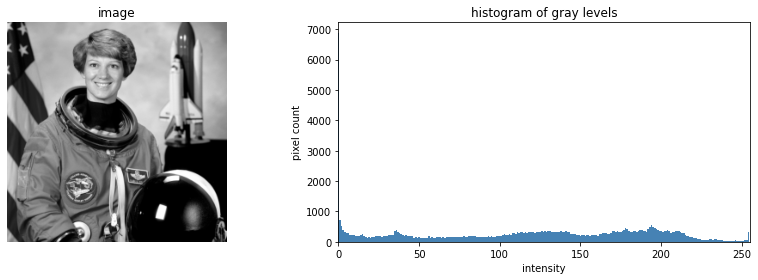

In [22]:
hist, bins = np.histogram(img_array, bins=256, range=(0, 256))
print("hist.shape =", hist.shape, "| total counts =", hist.sum(), "= number of pixels")
print("most common gray level:", hist.argmax(), "with", hist.max(), "pixels")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(img_array, cmap='gray', vmin=0, vmax=255); ax[0].set_title("image"); ax[0].axis('off')
ax[1].bar(bins[:-1], hist, width=1.0, color='steelblue')
ax[1].set_title("histogram of gray levels"); ax[1].set_xlim(0, 255)
ax[1].set_xlabel("intensity"); ax[1].set_ylabel("pixel count")
plt.tight_layout(); plt.show()

### A6 — Reshaping, stacking, building a colour image from channels

original shape : (256, 256) -> ndim = 2
flattened      : (65536,)
restored       : (256, 256)
as 512x128     : (512, 128)

dstack -> colour shape: (256, 256, 3)


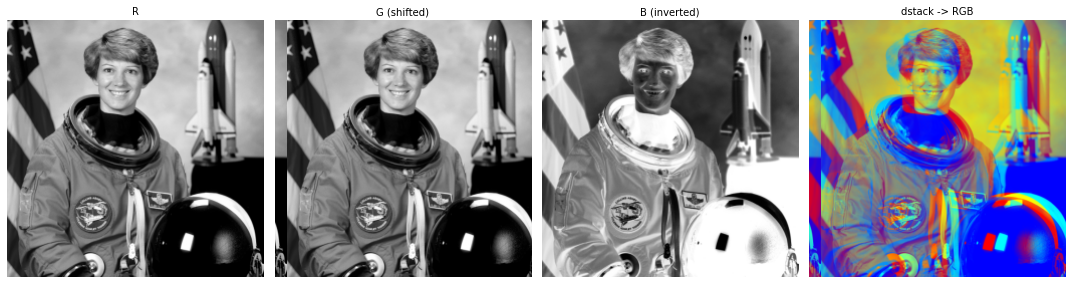

In [23]:
print("original shape :", img_array.shape, "-> ndim =", img_array.ndim)
flat = img_array.reshape(-1)
print("flattened      :", flat.shape)
print("restored       :", flat.reshape(256, 256).shape)
print("as 512x128     :", img_array.reshape(512, 128).shape)

R = img_array
G = np.roll(img_array, 12, axis=1)
B = 255 - img_array
colour = np.dstack([R, G, B])
print("\ndstack -> colour shape:", colour.shape)

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, (t, arr, cm_) in zip(ax, [("R", R, 'gray'), ("G (shifted)", G, 'gray'),
                                 ("B (inverted)", B, 'gray'), ("dstack -> RGB", colour, None)]):
    a.imshow(arr, cmap=cm_, vmin=None if cm_ is None else 0, vmax=None if cm_ is None else 255)
    a.set_title(t, fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

hstack: (256, 512) | vstack: (512, 512)


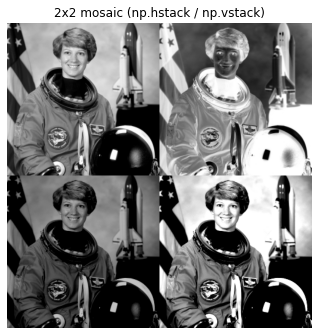

In [24]:
row = np.hstack([img_array, negative])
col = np.vstack([row, np.hstack([darker, contrast])])
print("hstack:", row.shape, "| vstack:", col.shape)

plt.figure(figsize=(5.5, 5.5))
plt.imshow(col, cmap='gray', vmin=0, vmax=255)
plt.title("2x2 mosaic (np.hstack / np.vstack)"); plt.axis('off'); plt.show()

### A7 — Downsampling and blending

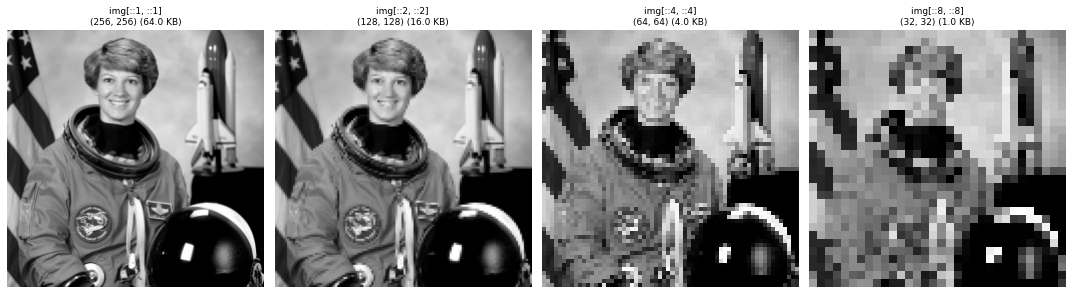

In [25]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for a, step in zip(ax, [1, 2, 4, 8]):
    small = img_array[::step, ::step]
    a.imshow(small, cmap='gray', vmin=0, vmax=255)
    a.set_title(f"img[::{step}, ::{step}]\n{small.shape} ({small.nbytes/1024:.1f} KB)", fontsize=9)
    a.axis('off')
plt.tight_layout(); plt.show()

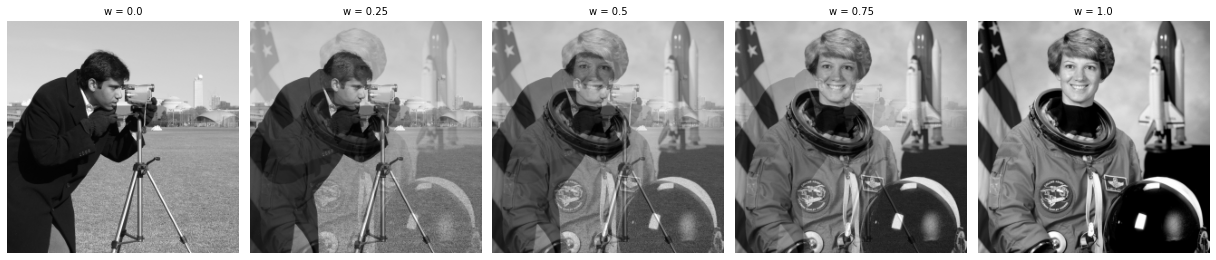

In [26]:
other = cv2.resize(img_gray, (256, 256))
fig, ax = plt.subplots(1, 5, figsize=(17, 3.8))
for a, w in zip(ax, [0.0, 0.25, 0.5, 0.75, 1.0]):
    blend = np.clip(w * img_array.astype(np.float32) +
                    (1 - w) * other.astype(np.float32), 0, 255).astype(np.uint8)
    a.imshow(blend, cmap='gray', vmin=0, vmax=255); a.set_title(f"w = {w}", fontsize=10); a.axis('off')
plt.tight_layout(); plt.show()

### A8 — Data types: uint8 vs float

In [27]:
as_float = img_array.astype(np.float32) / 255.0
back     = (as_float * 255).astype(np.uint8)

print(f"uint8   : range [{img_array.min()}, {img_array.max()}], {img_array.nbytes:,} bytes")
print(f"float32 : range [{as_float.min():.3f}, {as_float.max():.3f}], {as_float.nbytes:,} bytes")
print("round-trip lossless?", np.array_equal(back, img_array))

uint8   : range [0, 254], 65,536 bytes
float32 : range [0.000, 0.996], 262,144 bytes
round-trip lossless? True


## Outcome #1 — How digital images are represented and manipulated

A digital image **is** a NumPy array of integers. Grayscale is 2-D `(height, width)`; colour is 3-D `(height, width, 3)`.
Each element is a pixel — an intensity sample quantised to 8 bits, `0` = black to `255` = white — indexed as `[row, col]`
with the origin at the top-left. Storage is `height × width × channels` bytes (here 256 × 256 × 1 = 65,536).

Because the image is an array, every operation above is plain array arithmetic:

| Operation | NumPy mechanism |
|---|---|
| Crop / region of interest | slicing — `img[r0:r1, c0:c1]` |
| Flip, rotate, transpose | index reversal — `img[::-1]`, `img.T`, `np.rot90` |
| Brightness, contrast, gamma | scalar arithmetic + `np.clip` |
| Negative | `255 - img` |
| Thresholding / segmentation | boolean masks — `img > T` |
| Downsampling | strided slicing — `img[::n, ::n]` |
| Blending | weighted sum of two arrays |
| Histogram / statistics | `np.histogram`, `.mean()`, `.std()` |
| Colour construction | `np.dstack` of three 2-D channels |
